In [1]:
library(ggplot2)
library(ggrepel)
library(reshape2)
library(msigdbr)
library(Seurat)
library(SeuratData)
library(PaaSc)

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.2.3”
Warning message:
“package ‘reshape2’ was built under R version 4.2.3”
Loading required package: SeuratObject

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.2.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Installed datasets ──────────────────────────────── SeuratData v0.2.2.9001 ──

✔ stxBrain 0.1.2                        


────────────────────────────────────── Key ─────────────────────────────────────

✔ Dataset loaded successfully
❯ Dataset built with a newer version of Seurat than installed
❓ Unknown version of Seurat installed


Warning message:
“replacing previous import ‘data.table::shift’ by ‘tictoc::shift’ when loading ‘CelliD’”


## Data preparation
We use the pbmc3k data from SeuratData. See [spatial_vignette](https://satijalab.org/seurat/articles/spatial_vignette). 

In [2]:
InstallData("stxBrain")
brain <- LoadData("stxBrain", type = "posterior1")

Warning message:
“The following packages are already installed and will not be reinstalled: stxBrain”
Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in Spatial

Updating slots in posterior1

Validating object structure for Assay5 ‘Spatial’

Validating object structure for VisiumV2 ‘posterior1’

Object representation is consistent with the most current Seurat version



## Dimensionality reduction, clustering, and visualization
Data preprocess use the same workflow as scRNA-seq analysis.

In [ ]:
# normalize data by SCTransform, stores the data in the SCT assay.
options(matrixStats.useNames.NA = "deprecated")
brain <- SCTransform(brain, assay = "Spatial", verbose = FALSE)

# dimensionality reduction and clustering
brain <- RunPCA(brain, assay = "SCT", verbose = FALSE)
brain <- FindNeighbors(brain, reduction = "pca", dims = 1:30, verbose = FALSE)
brain <- FindClusters(brain, verbose = FALSE)
brain <- RunUMAP(brain, reduction = "pca", dims = 1:30, verbose = FALSE)

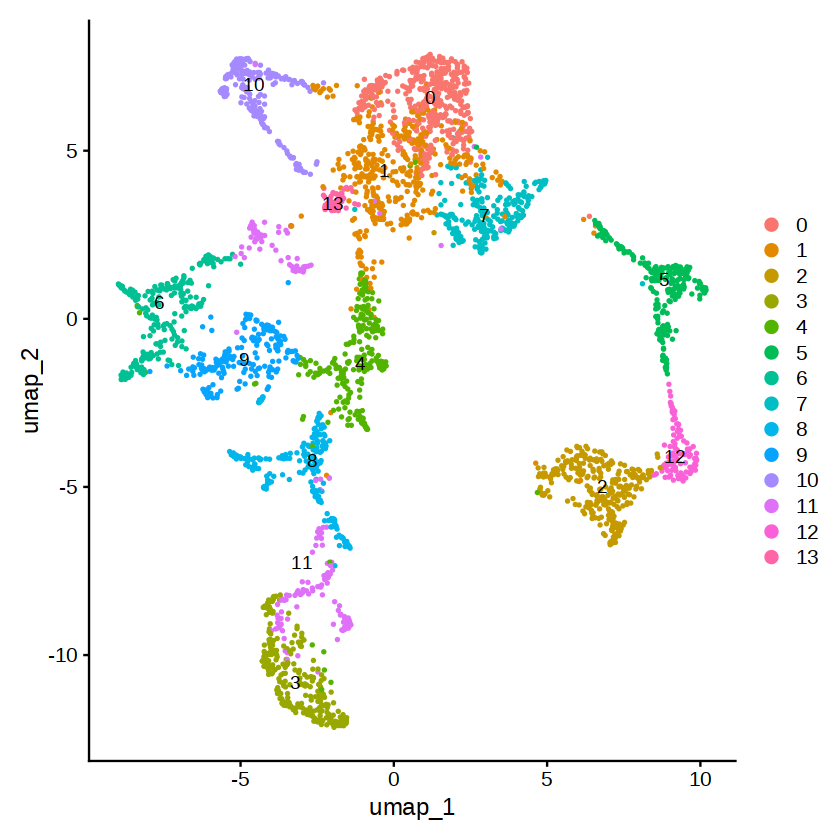

In [58]:
# visualize the cluster label in UMAP space
DimPlot(brain, reduction = "umap", label = TRUE)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


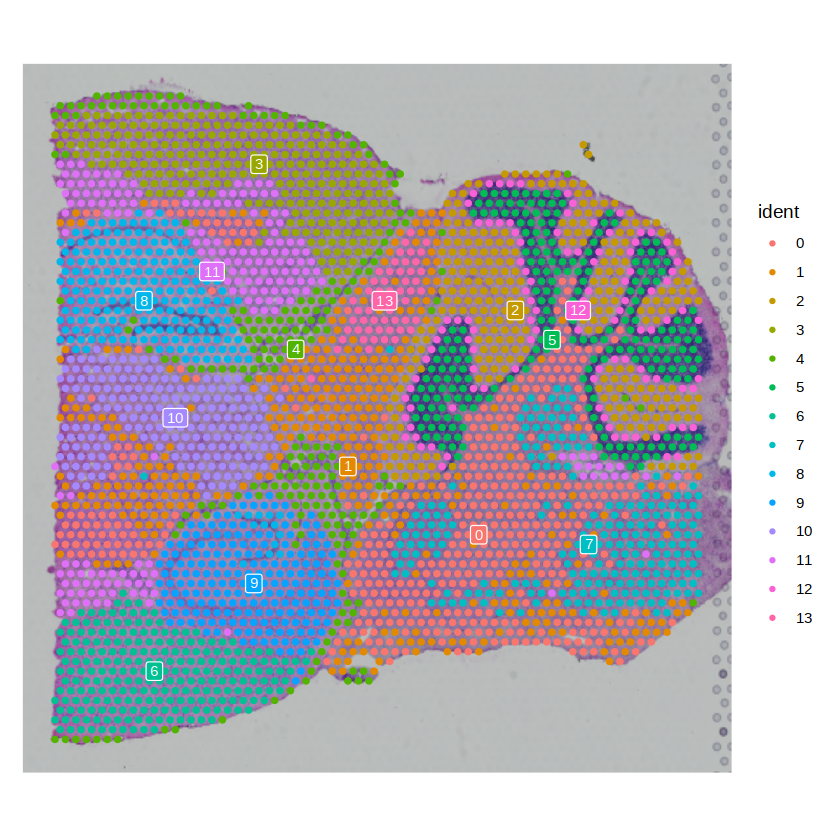

In [57]:
# visualize the cluster label in image
SpatialDimPlot(brain, label = TRUE, label.size = 3)

## Compute single-cell pathway activity score
Here we use GO Biological Process ontology as background gene sets downloaded from msigdbr package.

In [4]:
mm_c5 <- msigdbr(species = "Mus musculus", category = "C5")
mm_c5_gobp <- mm_c5[mm_c5$gs_subcat == "GO:BP", ]
background_geneset <- list()
for (geneset_name in unique(mm_c5_gobp$gs_name)) {
    background_geneset[[geneset_name]] <- mm_c5_gobp[mm_c5_gobp$gs_name %in% geneset_name, ]$gene_symbol
}
length(background_geneset)

[1] 7656

In [ ]:
brain <- computeMCA(brain, nmcs = 20, assay = "SCT")
pathway_geneset <- background_geneset[sapply(background_geneset, length) > 20 & sapply(background_geneset, length) < 300]
gene_rate <- getGeneRate(background.geneset = background_geneset, pathway.geneset = pathway_geneset)
regression_data <- doRegression(brain, gene.rate = gene_rate)
score_data <- computeScore(brain, regression.data = regression_data, pvalue = 0.05, weight = FALSE, normalize = "z-score")
score_data[1:5, 1:5]

Computing Fuzzy Matrix



1.276 sec elapsed


Computing SVD



1.635 sec elapsed


Computing Coordinates



0.353 sec elapsed


## Calculate spatial mutual information
Calculate the spatial mutual information between pathway activity score and cell position. High mutual information means more heterogeneity of pathway.

In [34]:
score_data <- score_data[, colSums(is.na(score_data)) == 0]
x <- GetTissueCoordinates(brain@images$posterior1)$x
y <- GetTissueCoordinates(brain@images$posterior1)$y
spatialMI <- calculateSpatialMI(x = x, y = y, z = score_data)
head(spatialMI)

Calculate spatial mutual information...

Do permutations...



,MI,pvalue
,<dbl>,<dbl>
GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METABOLIC_PROCESS,0.6069466,2.231626e-06
GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,0.7367835,9.386774e-11
GOBP_ACETYL_COA_METABOLIC_PROCESS,1.3340240,2.166364e-48
GOBP_ACIDIC_AMINO_ACID_TRANSPORT,0.6749958,1.668344e-08
GOBP_ACID_SECRETION,0.3623583,1.092239e-01
GOBP_ACROSOME_REACTION,1.5290024,5.870830e-67


In [46]:
# filter insignificant pathways and sort
spatialMI_filtered <- spatialMI[spatialMI$pvalue < 0.05, ]
spatialMI_sorted <- spatialMI_filtered[order(-spatialMI_filtered$MI), ]
head(spatialMI_sorted, 50)

,MI,pvalue
,<dbl>,<dbl>
GOBP_ADENYLATE_CYCLASE_ACTIVATING_ADRENERGIC_RECEPTOR_SIGNALING_PATHWAY,1.670298,2.374894e-82
GOBP_ADRENERGIC_RECEPTOR_SIGNALING_PATHWAY,1.656265,9.491175e-81
GOBP_REGULATION_OF_WATER_LOSS_VIA_SKIN,1.643865,2.394718e-79
GOBP_POSITIVE_REGULATION_OF_ACUTE_INFLAMMATORY_RESPONSE,1.643802,2.434180e-79
GOBP_RESPONSE_TO_COCAINE,1.558860,4.484552e-70
GOBP_NEGATIVE_REGULATION_OF_BLOOD_PRESSURE,1.554970,1.153340e-69
GOBP_ADENYLATE_CYCLASE_INHIBITING_G_PROTEIN_COUPLED_RECEPTOR_SIGNALING_PATHWAY,1.543126,2.010881e-68
GOBP_ACROSOME_REACTION,1.529002,5.870830e-67
GOBP_ACTIVATED_T_CELL_PROLIFERATION,1.529002,5.870830e-67


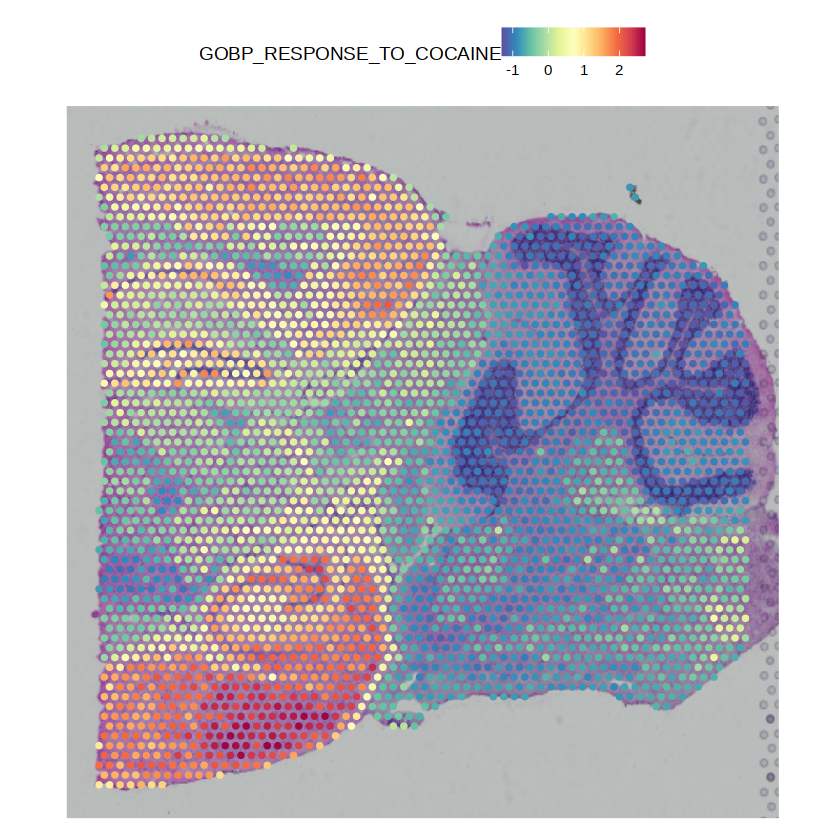

In [40]:
# visual some interesting pathway
pathway <- "GOBP_RESPONSE_TO_COCAINE"
brain@meta.data[pathway] <- score_data[, pathway]
SpatialFeaturePlot(brain, features = pathway)

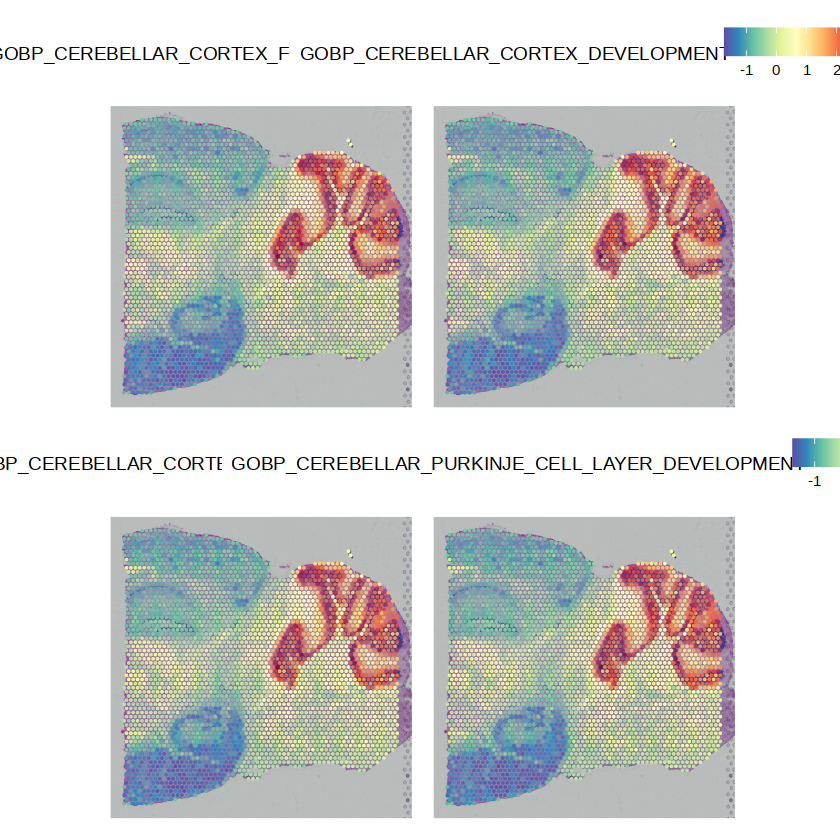

In [45]:
pathway <- c("GOBP_CEREBELLAR_CORTEX_FORMATION", "GOBP_CEREBELLAR_CORTEX_DEVELOPMENT", "GOBP_CEREBELLAR_CORTEX_MORPHOGENESIS", "GOBP_CEREBELLAR_PURKINJE_CELL_LAYER_DEVELOPMENT")
brain@meta.data[pathway] <- score_data[, pathway]
SpatialFeaturePlot(brain, features = pathway)